This notebook demonstrates the SPACE-GM workflow for extracting disease-associated spatial omics signatures:

1. Train models on MIF data and extract embeddings
2. Perform clustering on embeddings to derive spatial omics signatures, i.e., TME clusters

In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pickle
import pandas as pd
import networkx as nx
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from copy import deepcopy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import spacegm

from utils.set_seed import seed_everything

seed = 123
seed_everything(seed)
device = 'cpu'

## 1. Define Dataset

In [ ]:
raw_data_root = '/path/to/upmc_raw_data'  # TODO: path to upmc_raw_data directory
label_file = "/path/to/upmc_labels.csv"   # TODO: path to upmc_labels.csv

label_df = pd.read_csv(label_file)

region_ids = sorted(os.listdir(raw_data_root))
region_ids = [r_id for r_id in region_ids if \
    r_id in set(label_df['region_id']) \
    and os.path.exists(os.path.join(raw_data_root, r_id, f'{r_id}.cell_types.csv'))]
print(f"Total: {len(region_ids)} regions")

In [3]:
# Check if all files exist
for region_id in region_ids:
    assert all([
        os.path.exists(os.path.join(raw_data_root, region_id, f'{region_id}.cell_data.csv')),
        os.path.exists(os.path.join(raw_data_root, region_id, f'{region_id}.expression.csv')),
        os.path.exists(os.path.join(raw_data_root, region_id, f'{region_id}.cell_types.csv'))])

In [ ]:
# Generate cellular graphs from raw inputs
root_path = './assets'
dataset_root = os.path.join(root_path, "spacegm_upmc")
nx_graph_root = os.path.join(dataset_root, "graph")
fig_save_root = os.path.join(dataset_root, "fig")
model_save_root = os.path.join(dataset_root, "model")

os.makedirs(nx_graph_root, exist_ok=True)
os.makedirs(fig_save_root, exist_ok=True)
os.makedirs(model_save_root, exist_ok=True)

nx_graph_files = []
for region_id in region_ids:
    graph_output = os.path.join(nx_graph_root, "%s.gpkl" % region_id)
    nx_graph_files.append(graph_output)
    if not os.path.exists(graph_output):
        print("Processing %s" % region_id)
        G = spacegm.construct_graph_for_region(
            region_id,
            cell_coords_file=os.path.join(raw_data_root, region_id, f'{region_id}.cell_data.csv'),
            cell_types_file=os.path.join(raw_data_root, region_id, f'{region_id}.cell_types.csv'),
            cell_biomarker_expression_file=os.path.join(raw_data_root, region_id, f'{region_id}.expression.csv'),
            cell_features_file=None,
            voronoi_file=None,
            graph_source='cell',
            graph_output=graph_output,
            voronoi_polygon_img_output=os.path.join(fig_save_root, f"{region_id}_voronoi.png"),
            graph_img_output=os.path.join(fig_save_root, f"{region_id}_graph.png"))

In [5]:
shared_biomarkers, _ = spacegm.utils.get_biomarker_metadata(nx_graph_files)
cell_type_mapping, cell_type_freq = spacegm.utils.get_cell_type_metadata(nx_graph_files)

In [6]:
# Define dataset
dataset_kwargs = {
    'raw_folder_name': 'graph',
    'processed_folder_name': 'tg_graph',
    'node_features': ["cell_type",  "biomarker_expression", "neighborhood_composition", "center_coord"],  # "SIZE",
    'edge_features': ["edge_type", "distance"],
    'cell_type_mapping': cell_type_mapping,
    'cell_type_freq': cell_type_freq,
    'biomarkers': shared_biomarkers,
    'subgraph_size': 3,  # 3-hop subgraph
    'subgraph_source': 'on-the-fly',
    'subgraph_allow_distant_edge': True,
    'subgraph_radius_limit': 200,  # 200 pixels ~ 55 um for neighborhood cutoff
}

feature_kwargs = {
    "biomarker_expression_process_method": "log",
    "biomarker_expression_lower_bound": 3,
    "biomarker_expression_upper_bound": 8,
    "neighborhood_size": 10,
}

dataset_kwargs.update(feature_kwargs)
dataset = spacegm.CellularGraphDataset(dataset_root, **dataset_kwargs)
# dataset.process()  # If new regions are added

## 2. Model training

### 2.1. Define Prediction Task

In [7]:
# Define Transformers
graph_tasks = ['primary_outcome']
use_node_features = ['cell_type']

transformers = [
    spacegm.FeatureMask(
        dataset,
        use_center_node_features=use_node_features,
        use_neighbor_node_features=use_node_features),
    spacegm.AddGraphLabel(label_file, tasks=graph_tasks),
]
dataset.set_transforms(transformers)

train_idx = np.arange(dataset.N)  # All data used for training

### 2.2. Train GNNs to predict

In [8]:
## Training settings
model_kwargs = {
    'num_layer': dataset.subgraph_size,
    'num_node_type': len(dataset.cell_type_mapping) + 1,
    'num_feat': dataset[0].x.shape[1] - 1,
    'emb_dim': 512,
    'num_node_tasks': 0,
    'num_graph_tasks': len(graph_tasks),
    'node_embedding_output': 'last',
    'drop_ratio': 0.25,
    'graph_pooling': "max",
    'gnn_type': 'gin',
}

train_kwargs = {
    'batch_size': 64,
    'lr': 0.001,
    'graph_loss_weight': 1.0,
    'num_iterations': 5e4,  # Total number of training iterations
    'num_regions_per_segment': 0,
    'num_iterations_per_segment': 1e6,
    'num_workers': 8,

    'node_task_loss_fn': None,
    'graph_task_loss_fn': spacegm.models.BinaryCrossEntropy(),
    'evaluate_fn': [
        spacegm.train.evaluate_by_sampling_subgraphs,
        spacegm.train.save_model_weight,
    ],
    'evaluate_freq': 1e3,  # Interval for model saving and evaluations
    'evaluate_on_train': True,
}


In [ ]:
# Train models for all regions
# Treat each subgraph as a unit, evaluate prediction performance on graph label prediction
evaluate_kwargs = {
    'num_eval_iterations': 100,
    'graph_task_evaluate_fn': spacegm.inference.graph_classification_evaluate_fn,
    'score_file': os.path.join(model_save_root, f'GIN-{graph_tasks[0]}-upmc-all.txt'),
    'model_folder': os.path.join(model_save_root, f'GIN-{graph_tasks[0]}-upmc-all'),
}

train_kwargs.update(evaluate_kwargs)
os.makedirs(evaluate_kwargs['model_folder'], exist_ok=True)
model = spacegm.models.GNN_pred(**model_kwargs)
model = spacegm.train.train_subgraph(
    model, dataset, device,
    train_inds=train_idx, valid_inds=train_idx, **train_kwargs)

## 3. Embedding Analysis

In [11]:
from spacegm.embeddings_analysis import (
    get_random_sampled_subgraphs,
    get_embedding,
    get_composition_vector,
    get_composition_heatmap_for_cluster,
    dimensionality_reduction_combo,
    collect_cluster_label_for_all_nodes,
)

In [12]:
# Randomly sample subgraphs from the dataset as reference
N_SAMPLES = 50000
reference_subgraph_list = get_random_sampled_subgraphs(dataset, n_samples=N_SAMPLES)

In [13]:
# Get trained model for generating embeddings
model_kwargs = {
    'num_layer': dataset.subgraph_size,
    'num_node_type': len(dataset.cell_type_mapping) + 1,
    'num_feat': dataset[0].x.shape[1] - 1,
    'emb_dim': 512,
    'num_node_tasks': 0,
    'num_graph_tasks': len(graph_tasks),
    'node_embedding_output': 'last',
    'drop_ratio': 0.25,
    'graph_pooling': "max",
    'gnn_type': 'gin',
}
model = spacegm.models.GNN_pred(**model_kwargs)
model.load_state_dict(torch.load(os.path.join(model_save_root, f'GIN-{graph_tasks[0]}-upmc-all', 'model.pt')))  # TODO: CHANGE to the corresponding model weight path
model = model.to(device)
model = model.eval()

### 3.1. Acquire graph embeddings and clustering

In [ ]:
# Acquire node embeddings and graph embeddings for the sampled subgraphs using a trained GNN model
ref_node_embeddings, ref_graph_embeddings, (ref_node_preds, ref_graph_preds) = \
    get_embedding(model, reference_subgraph_list, device)

# Acquire discrete annotations from embeddings through dimensionality reduction and clustering 
n_clusters = 15
ref_pca_embs, ref_umap_emb, ref_cluster_labels, (pca, reducer, km_clustering) = \
    dimensionality_reduction_combo(ref_graph_embeddings, n_pca_components=20, cluster_method='kmeans', n_clusters=n_clusters)

# Acquire basic description of the spatial omics-based clusters: each cluster's cell type composition, association with label (primary outcome)
heatmap, enrichment, cluster_preds, cluster_counts = \
    get_composition_heatmap_for_cluster(reference_subgraph_list, ref_cluster_labels, ref_graph_preds)

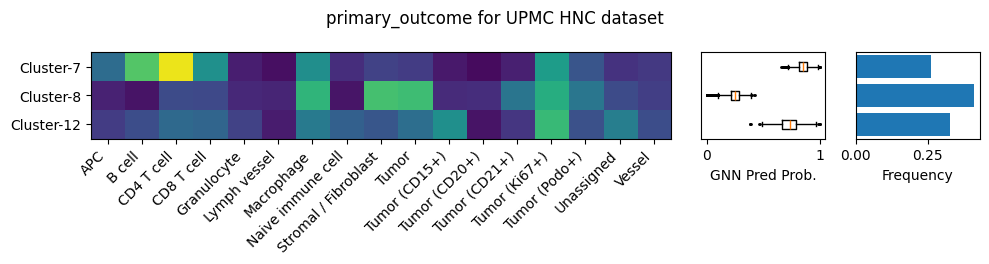

In [15]:
from matplotlib import rcParams

rcParams.update({"font.size": 10})

# Visualize the basic description
plot_cluster_labels = np.array(ref_cluster_labels).flatten()
plot_graph_preds = 1 / (1 + np.exp(-np.array(ref_graph_preds).flatten()))  # Sigmoid

ctm = dataset.cell_type_mapping

# Select representative clusters for visualization
_clusters = [7, 8, 12]
_heatmap = heatmap[_clusters]
n_clusters = len(_clusters)
figsize = (10, 2.65)
vmax = 0.2

f, (a0, a1, a2) = plt.subplots(1, 3, figsize=figsize, gridspec_kw={'width_ratios': [14, 3, 3]})

# ax0: Heatmap of cell type enrichment
a0.imshow(_heatmap, vmin=0, vmax=vmax, cmap='viridis', aspect='auto', extent=[0, len(ctm), 0, n_clusters])
a0.set_xticks(np.array([ctm[ct] for ct in sorted(ctm.keys())]) + 0.5,
              sorted(ctm.keys()), rotation=45, ha='right')
a0.set_yticks(np.arange(n_clusters - 1, -1, -1) + 0.5, ["Cluster-%d" % o for o in _clusters])

# ax1: Box plot of predicted probabilities for each neighborhood
xs = [plot_graph_preds[np.where(plot_cluster_labels == cl)[0]] for cl in _clusters]
a1.boxplot(xs, vert=False, positions=np.arange(n_clusters), flierprops=dict(marker='.', markersize=2))
a1.set_ylim(n_clusters - 0.5, -0.5)
a1.set_xlabel("GNN Pred Prob.")
a1.set_yticks([])

# ax2: Bar plot of neighborhood count in the sampled reference subgraphs
counts_ar = [len(x) for x in xs]
freq_ar = np.array(counts_ar)/np.sum(counts_ar)
a2.barh(np.arange(n_clusters), freq_ar, align='center')
a2.set_yticks([])
a2.set_ylim(n_clusters - 0.5, -0.5)
a2.set_xlabel("Frequency")

plt.suptitle(f"{graph_tasks[0]} for UPMC HNC dataset")
plt.tight_layout()
plt.show()

### 3.2 Record Annotations

In [17]:
# Record clusters and their coordinates as annotations to the subgraphs
anno_clusters = [i for i in range(n_clusters)]

xcoord_ind = dataset.node_feature_names.index('center_coord-x')
ycoord_ind = dataset.node_feature_names.index('center_coord-y')

anno_list = []
for i in range(len(reference_subgraph_list)):
    ref_subgraph = reference_subgraph_list[i]
    region_id_idx = region_ids.index(ref_subgraph.region_id)
    subgraph = dataset.get_subgraph(region_id_idx, ref_subgraph.original_center_node)
    coords = subgraph.x.data.numpy()[:, [xcoord_ind, ycoord_ind]].astype(int)
    x_c, y_c = coords[subgraph.center_node_index]
    x_max, y_max = coords.max(axis=0)
    x_min, y_min = coords.min(axis=0)
    if x_max == x_min or y_max == y_min:
        continue
    cluster_label = ref_cluster_labels[i]
    if cluster_label not in anno_clusters:
        cl = len(anno_clusters)
    else:
        cl = anno_clusters.index(cluster_label)
    anno_list.append([ref_subgraph.region_id, x_c, y_c, cl, x_max, x_min, y_max, y_min])
    
anno_df = pd.DataFrame(anno_list, columns=['region_id', 'centerX', 'centerY', 'cluster', 'maxX', 'minX', 'maxY', 'minY'])
anno_df.to_csv(f"./data/microE_annotations/new_upmc_microE_anno_{graph_tasks[0]}_ALL.csv", index=False)
print(len(anno_df))

49995
